In [1]:
import io, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt, soundfile as sf
from datasets import load_dataset, Audio

LABEL_HOP = 512          # each reference label covers 512 samples = 32 ms at 16 kHz

In [2]:
dataset = load_dataset("guynich/librispeech_asr_test_vad", split="test.clean")
dataset = dataset.cast_column("audio", Audio(decode=False))

# LibriSpeech file names look like 6930-75918-0000: speaker - chapter - utterance
file_names = dataset["file"]
speaker_of = [os.path.basename(str(f)).split("-")[0] for f in file_names]

N_PER_SPEAKER = 5
rng = np.random.default_rng(42)
selected = []
for speaker in sorted(set(speaker_of)):
    idx = [i for i, s in enumerate(speaker_of) if s == speaker]
    selected += list(rng.choice(idx, size=min(N_PER_SPEAKER, len(idx)), replace=False))

print("Utterances in the split:", len(file_names), "| Speakers:", len(set(speaker_of)), "| Selected recordings:", len(selected))

Utterances in the split: 2620 | Speakers: 40 | Selected recordings: 200


In [3]:
recordings = []
for i in selected:
    sample = dataset[int(i)]
    audio = sample["audio"]
    source = io.BytesIO(audio["bytes"]) if audio["bytes"] is not None else audio["path"]
    y, sr = sf.read(source)
    if y.ndim > 1:
        y = y.mean(axis=1)
    reference = np.asarray(sample["speech"], dtype=int)
    valid = np.asarray(sample["confidence"], dtype=int) == 1
    n_blocks = len(reference)
    if len(y) < n_blocks * LABEL_HOP:                      # pad if the last block is incomplete
        y = np.pad(y, (0, n_blocks * LABEL_HOP - len(y)))
    recordings.append({"id": os.path.basename(str(sample["file"])), "speaker": speaker_of[i], "y": y,
                       "reference": reference, "valid": valid, "n_blocks": n_blocks})

total = sum(int(r["valid"].sum()) for r in recordings)
speech = sum(int((r["reference"][r["valid"]] == 1).sum()) for r in recordings)
print("Recordings:", len(recordings), "| Total audio:", round(sum(len(r["y"]) for r in recordings) / sr / 60, 1), "min")
print("Evaluated labels:", total, "| Speech:", speech, f"({speech / total:.1%}) | Non-speech:", total - speech)

Recordings: 200 | Total audio: 25.6 min
Evaluated labels: 44686 | Speech: 36743 (82.2%) | Non-speech: 7943


Recordings with less than 20% non-speech: 60 / 200
Recordings with less than 10% non-speech: 0 / 200
Recordings with speech in the first 0.5 s: 118 / 200


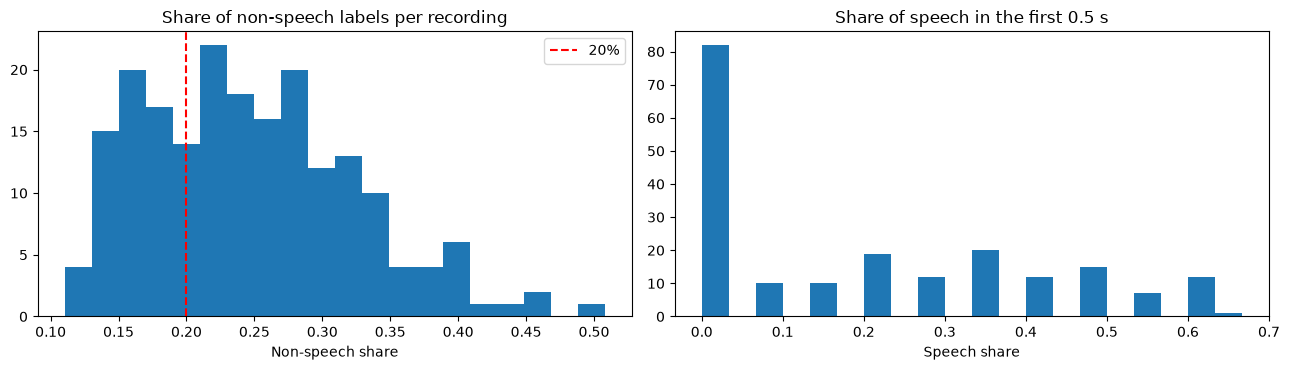

In [4]:
lead = int(0.5 * sr / LABEL_HOP)                           # number of labels in the first 0.5 s
for r in recordings:
    r["nonspeech_share"] = float((r["reference"] == 0).mean())
    r["leading_speech_share"] = float(r["reference"][:lead].mean())

info = pd.DataFrame([{k: r[k] for k in ["id", "speaker", "nonspeech_share", "leading_speech_share"]} for r in recordings])

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].hist(info["nonspeech_share"], bins=20)
axes[0].axvline(0.20, color="red", linestyle="--", label="20%")
axes[0].set_title("Share of non-speech labels per recording"); axes[0].set_xlabel("Non-speech share"); axes[0].legend()
axes[1].hist(info["leading_speech_share"], bins=20)
axes[1].set_title("Share of speech in the first 0.5 s"); axes[1].set_xlabel("Speech share")
plt.tight_layout(); plt.show()

print("Recordings with less than 20% non-speech:", int((info["nonspeech_share"] < 0.20).sum()), "/", len(info))
print("Recordings with less than 10% non-speech:", int((info["nonspeech_share"] < 0.10).sum()), "/", len(info))
print("Recordings with speech in the first 0.5 s:", int((info["leading_speech_share"] > 0).sum()), "/", len(info))

In [5]:
def block_rms(signal, n_blocks):
    """RMS energy of each 512-sample block (same grid as the reference labels)."""
    blocks = signal[:n_blocks * LABEL_HOP].reshape(n_blocks, LABEL_HOP)
    return np.sqrt(np.mean(blocks ** 2, axis=1))

def to_db(values):
    return 20 * np.log10(values + 1e-10)

def counts(true, pred):
    """Confusion counts; these are summed over recordings before computing rates."""
    return {"TP": int(np.sum((true == 1) & (pred == 1))), "TN": int(np.sum((true == 0) & (pred == 0))),
            "FP": int(np.sum((true == 0) & (pred == 1))), "FN": int(np.sum((true == 1) & (pred == 0)))}

def rates(c):
    """Miss rate, false alarm rate and balanced accuracy from (summed) counts."""
    miss = c["FN"] / (c["TP"] + c["FN"]) if c["TP"] + c["FN"] else np.nan
    fa = c["FP"] / (c["FP"] + c["TN"]) if c["FP"] + c["TN"] else np.nan
    return pd.Series({"miss_rate": miss, "false_alarm_rate": fa, "balanced_accuracy": 1 - (miss + fa) / 2})

def make_noise(n, kind, rng):
    """white: flat spectrum | pink: more low-frequency power | fluctuating: pink noise whose level drifts over time."""
    white = rng.normal(size=n)
    if kind == "white":
        return white
    spectrum = np.fft.rfft(white)
    freqs = np.fft.rfftfreq(n)
    freqs[0] = freqs[1]
    pink = np.fft.irfft(spectrum / np.sqrt(freqs), n=n)
    if kind == "pink":
        return pink
    control = rng.normal(size=int(n / sr * 5) + 2) * 4.0
    gain_db = np.interp(np.arange(n), np.linspace(0, n, len(control)), control)
    return pink * 10 ** (gain_db / 20)

def noisy_rms(rec, kind, snr_db, seed):
    """Block RMS of the recording after adding noise (speech power measured on speech samples only)."""
    y, n_blocks = rec["y"], rec["n_blocks"]
    if kind == "clean":
        return block_rms(y, n_blocks)
    mask = np.zeros(len(y), dtype=bool)
    mask[:n_blocks * LABEL_HOP] = np.repeat(rec["reference"] == 1, LABEL_HOP)
    noise = make_noise(len(y), kind, np.random.default_rng(seed))
    signal_power = np.mean(y[mask] ** 2) if mask.any() else np.mean(y ** 2)
    noise = noise * np.sqrt(signal_power / (np.mean(noise ** 2) * 10 ** (snr_db / 10)))
    return block_rms(y + noise, n_blocks)

CONDITIONS = [("clean", None)] + [(kind, snr) for kind in ["white", "pink", "fluctuating"] for snr in [20, 10, 0]]

def cond_name(kind, snr):
    return "clean" if kind == "clean" else f"{kind} {snr} dB"

In [6]:
def floor_stats(rms_values):
    db = to_db(rms_values)
    p5, p10, p20 = np.percentile(db, [5, 10, 20])
    return p10, p20 - p5

def th_fixed_margin(rms_values, margin_db=6):
    return 10 ** ((floor_stats(rms_values)[0] + margin_db) / 20)

def th_leading(rms_values, margin_db=6):
    return 10 ** ((to_db(rms_values[:lead]).mean() + margin_db) / 20)

def th_spread_margin(rms_values, k=2.0, min_margin_db=1.0):
    floor, spread = floor_stats(rms_values)
    return 10 ** ((floor + max(k * spread, min_margin_db)) / 20)

def th_oracle(rms_values, rec):
    """Best threshold for this one recording, chosen with its labels (upper bound)."""
    true, valid = rec["reference"][rec["valid"]], rec["valid"]
    candidates = np.logspace(-3.5, -0.5, 100)
    scores = []
    for th in candidates:
        c = counts(true, (rms_values[valid] > th).astype(int))
        scores.append(rates(c)["balanced_accuracy"] if (c["TP"] + c["FN"]) and (c["FP"] + c["TN"]) else
                      (c["TP"] + c["TN"]) / max(len(true), 1))
    return candidates[int(np.argmax(scores))]

In [7]:
speakers = sorted(set(r["speaker"] for r in recordings))
shuffled = list(np.random.default_rng(7).permutation(speakers))
dev_speakers = set(shuffled[:len(speakers) // 4])          # a quarter of the speakers for tuning
for r in recordings:
    r["split"] = "dev" if r["speaker"] in dev_speakers else "test"

dev = [r for r in recordings if r["split"] == "dev"]
test = [r for r in recordings if r["split"] == "test"]
print("Dev :", len(dev_speakers), "speakers,", len(dev), "recordings")
print("Test:", len(speakers) - len(dev_speakers), "speakers,", len(test), "recordings")

Dev : 10 speakers, 50 recordings
Test: 30 speakers, 150 recordings


In [8]:
# Cache the block energies once: every recording in every condition
for index, r in enumerate(recordings):
    r["rms"] = {cond_name(kind, snr): noisy_rms(r, kind, snr, seed=index) for kind, snr in CONDITIONS}

def pooled(recs, condition, threshold_fn):
    """Sum the confusion counts over recordings for one condition and one threshold rule."""
    total = {"TP": 0, "TN": 0, "FP": 0, "FN": 0}
    for r in recs:
        rms_values = r["rms"][condition]
        c = counts(r["reference"][r["valid"]], (rms_values[r["valid"]] > threshold_fn(rms_values, r)).astype(int))
        for key in total:
            total[key] += c[key]
    return total

# (a) one global fixed threshold, tuned on the clean dev recordings
candidates = np.logspace(-3.5, -1, 60)
dev_scores = [rates(pooled(dev, "clean", lambda v, r, th=th: th))["balanced_accuracy"] for th in candidates]
global_th = candidates[int(np.argmax(dev_scores))]
print(f"Global fixed threshold tuned on dev (clean): {global_th:.4f} ({to_db(global_th):.1f} dB)")

# (b) k of the spread-based margin, tuned on all dev conditions
all_conditions = [cond_name(kind, snr) for kind, snr in CONDITIONS]
k_rows = []
for k in [0.5, 1.0, 1.5, 2.0, 3.0]:
    acc = [rates(pooled(dev, c, lambda v, r, k=k: th_spread_margin(v, k)))["balanced_accuracy"] for c in all_conditions]
    k_rows.append({"k": k, "mean balanced accuracy (dev)": np.mean(acc), "clean only": acc[0]})
k_table = pd.DataFrame(k_rows)
best_k = float(k_table.loc[k_table["mean balanced accuracy (dev)"].idxmax(), "k"])
display(k_table.round(3)); print("k chosen on dev:", best_k)

Global fixed threshold tuned on dev (clean): 0.0142 (-36.9 dB)
k chosen on dev: 1.5


,k,mean balanced accuracy (dev),clean only
0,0.5,0.786,0.842
1,1.0,0.816,0.865
2,1.5,0.822,0.826
3,2.0,0.811,0.769
4,3.0,0.761,0.686


In [9]:
METHODS = {
    "global fixed (dev-tuned)": lambda v, r: global_th,
    "fixed margin 6 dB": lambda v, r: th_fixed_margin(v),
    "leading 0.5 s + 6 dB": lambda v, r: th_leading(v),
    "spread-based (k=2, from EXP-03)": lambda v, r: th_spread_margin(v, 2.0),
    f"spread-based (k={best_k}, dev-tuned)": lambda v, r: th_spread_margin(v, best_k),
    "oracle (per recording)": th_oracle,
}

rows = []
for r in recordings:
    true = r["reference"][r["valid"]]
    for condition in all_conditions:
        rms_values = r["rms"][condition]
        for method, fn in METHODS.items():
            pred = (rms_values[r["valid"]] > fn(rms_values, r)).astype(int)
            rows.append({"id": r["id"], "speaker": r["speaker"], "split": r["split"], "condition": condition,
                         "method": method, **counts(true, pred)})
results = pd.DataFrame(rows)
print("Rows:", len(results))

Rows: 12000


In [10]:
def summarise(frame, by):
    """Sum the counts within each group, then turn them into rates."""
    return frame.groupby(by, observed=True)[["TP", "TN", "FP", "FN"]].sum().apply(rates, axis=1)

test_results = results[results["split"] == "test"]
table = summarise(test_results, ["method", "condition"])["balanced_accuracy"].unstack()[all_conditions].loc[list(METHODS)]
table["mean"] = table.mean(axis=1)
table["gap to oracle"] = table.loc["oracle (per recording)", "mean"] - table["mean"]
display(table.round(3))

condition,clean,white 20 dB,white 10 dB,white 0 dB,pink 20 dB,pink 10 dB,pink 0 dB,fluctuating 20 dB,fluctuating 10 dB,fluctuating 0 dB,mean,gap to oracle
method,,,,,,,,,,,,
global fixed (dev-tuned),0.904,0.908,0.588,0.500,0.904,0.636,0.501,0.897,0.682,0.505,0.703,0.166
fixed margin 6 dB,0.913,0.925,0.794,0.542,0.922,0.826,0.614,0.905,0.819,0.654,0.791,0.077
leading 0.5 s + 6 dB,0.897,0.883,0.746,0.531,0.883,0.758,0.552,0.877,0.757,0.578,0.746,0.122
"spread-based (k=2, from EXP-03)",0.798,0.925,0.926,0.822,0.889,0.823,0.681,0.866,0.787,0.642,0.816,0.052
"spread-based (k=1.5, dev-tuned)",0.857,0.930,0.930,0.822,0.895,0.819,0.684,0.889,0.809,0.658,0.829,0.039
oracle (per recording),0.961,0.957,0.939,0.845,0.940,0.860,0.714,0.930,0.841,0.696,0.868,0.000


In [11]:
transfer = summarise(results, ["method", "split"])["balanced_accuracy"].unstack().loc[list(METHODS)]
transfer["test - dev"] = transfer["test"] - transfer["dev"]
display(transfer.round(3))

split,dev,test,test - dev
method,,,
global fixed (dev-tuned),0.679,0.703,0.024
fixed margin 6 dB,0.783,0.791,0.008
leading 0.5 s + 6 dB,0.736,0.746,0.010
"spread-based (k=2, from EXP-03)",0.811,0.816,0.005
"spread-based (k=1.5, dev-tuned)",0.822,0.829,0.008
oracle (per recording),0.867,0.868,0.001


In [12]:
start = pd.DataFrame([{"id": r["id"], "start": "silent start" if r["leading_speech_share"] == 0 else "speech in first 0.5 s"}
                      for r in recordings])
merged = test_results.merge(start, on="id")
print(merged.drop_duplicates("id")["start"].value_counts())
display(summarise(merged[merged["method"].isin(["leading 0.5 s + 6 dB", "fixed margin 6 dB"])], ["method", "start"]).round(3))

start
speech in first 0.5 s    90
silent start             60
Name: count, dtype: int64


miss_rate  ...  balanced_accuracy
method               start                             ...                   
fixed margin 6 dB    silent start               0.341  ...              0.792
                     speech in first 0.5 s      0.354  ...              0.792
leading 0.5 s + 6 dB silent start               0.399  ...              0.776
                     speech in first 0.5 s      0.533  ...              0.727

[4 rows x 3 columns]

Hardest speakers (clean):


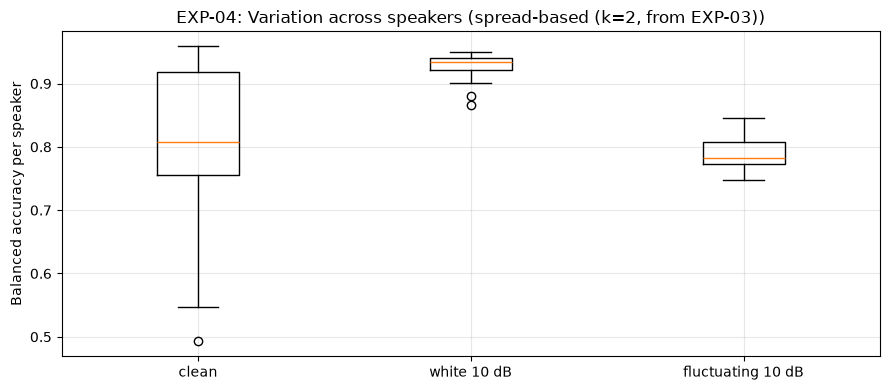

condition,clean,white 10 dB,fluctuating 10 dB
mean,0.801,0.928,0.791
std,0.130,0.019,0.027
min,0.493,0.866,0.748
max,0.959,0.949,0.845


speaker
121     0.493
1995    0.547
7729    0.589
8463    0.619
1580    0.652
Name: clean, dtype: float64

In [13]:
main_method = "spread-based (k=2, from EXP-03)"
per_speaker = summarise(test_results[test_results["method"] == main_method],
                        ["speaker", "condition"])["balanced_accuracy"].unstack()
show = ["clean", "white 10 dB", "fluctuating 10 dB"]

plt.figure(figsize=(9, 4))
plt.boxplot([per_speaker[c].dropna() for c in show])
plt.xticks(range(1, len(show) + 1), show)
plt.ylabel("Balanced accuracy per speaker"); plt.title(f"EXP-04: Variation across speakers ({main_method})")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

display(per_speaker[show].describe().loc[["mean", "std", "min", "max"]].round(3))
print("Hardest speakers (clean):"); display(per_speaker["clean"].sort_values().head(5).round(3))

In [14]:
share = pd.DataFrame([{"id": r["id"], "nonspeech_share": r["nonspeech_share"]} for r in recordings])
share["group"] = pd.cut(share["nonspeech_share"], [0, 0.10, 0.20, 1.0], labels=["< 10%", "10-20%", "> 20%"], include_lowest=True)
merged = test_results.merge(share, on="id")
by_share = summarise(merged[merged["method"].isin([main_method, "fixed margin 6 dB", "oracle (per recording)"])],
                     ["group", "method"])
print(merged.drop_duplicates("id")["group"].value_counts().sort_index())
display(by_share.round(3))

group
< 10%       0
10-20%     49
> 20%     101
Name: count, dtype: int64


miss_rate  ...  balanced_accuracy
group  method                                      ...                   
10-20% fixed margin 6 dB                    0.365  ...              0.789
       oracle (per recording)               0.180  ...              0.868
       spread-based (k=2, from EXP-03)      0.358  ...              0.797
> 20%  fixed margin 6 dB                    0.337  ...              0.795
       oracle (per recording)               0.173  ...              0.869
       spread-based (k=2, from EXP-03)      0.240  ...              0.835

[6 rows x 3 columns]

In [15]:
os.makedirs("../results", exist_ok=True)
table.to_csv("../results/exp04_methods_by_condition.csv")
per_speaker.to_csv("../results/exp04_per_speaker.csv")
by_share.to_csv("../results/exp04_by_nonspeech_share.csv")
print("Saved.")

Saved.


In [16]:
# Inspect the recordings of the speakers where the method fails on clean audio
rows = []
for r in recordings:
    if r["speaker"] in ["121", "1995", "7729"]:
        v = r["rms"]["clean"]
        floor, spread = floor_stats(v)
        rows.append({"id": r["id"], "nonspeech_share": r["nonspeech_share"],
                     "floor_db": floor, "spread_db": spread,
                     "threshold_db (k=2)": to_db(th_spread_margin(v, 2.0)),
                     "oracle_db": to_db(th_oracle(v, r)),
                     "median speech_db": np.median(to_db(v)[r["reference"] == 1])})
display(pd.DataFrame(rows).round(2))

# The same quantities averaged over all recordings, for comparison
everything = pd.DataFrame([{"nonspeech_share": r["nonspeech_share"], "spread_db": floor_stats(r["rms"]["clean"])[1]}
                           for r in recordings])
print("All recordings - mean non-speech share:", everything["nonspeech_share"].round(3).mean().round(3),
      "| mean spread:", everything["spread_db"].mean().round(2), "dB")

All recordings - mean non-speech share: 0.246 | mean spread: 13.81 dB


,id,nonspeech_share,floor_db,spread_db,threshold_db (k=2),oracle_db,median speech_db
0,121-127105-0010.flac,0.18,-78.06,104.18,130.30,-50.61,-29.29
1,121-127105-0028.flac,0.18,-200.00,148.95,97.90,-63.94,-28.90
2,121-127105-0006.flac,0.21,-103.59,133.33,163.07,-70.00,-30.66
3,121-127105-0002.flac,0.18,-76.10,50.38,24.66,-52.42,-28.61
4,121-121726-0011.flac,0.40,-200.00,0.00,-193.47,-62.12,-30.61
5,1995-1837-0022.flac,0.13,-78.70,72.26,65.82,-68.18,-21.54
6,1995-1826-0011.flac,0.17,-75.51,39.11,2.71,-45.76,-24.07
7,1995-1826-0007.flac,0.22,-77.97,24.59,-28.79,-44.55,-25.88
8,1995-1826-0013.flac,0.18,-57.61,34.20,10.79,-41.52,-21.24
9,1995-1837-0023.flac,0.15,-82.42,42.09,1.76,-61.52,-24.08


In [17]:
def th_robust(rms_values, k=1.5, cap_db=6.0, range_db=60.0):
    """Spread-based margin with two safeguards against a meaningless noise-floor estimate."""
    db = to_db(rms_values)
    db = np.maximum(db, np.percentile(db, 95) - range_db)      # treat digital silence as "very quiet", not -200 dB
    p5, p10, p20 = np.percentile(db, [5, 10, 20])
    margin = min(max(k * (p20 - p5), 1.0), cap_db)              # never trust an implausibly large spread
    return 10 ** ((p10 + margin) / 20)

rows = []
for r in recordings:
    true = r["reference"][r["valid"]]
    for condition in all_conditions:
        v = r["rms"][condition]
        pred = (v[r["valid"]] > th_robust(v)).astype(int)
        rows.append({"split": r["split"], "condition": condition, "method": "robust spread-based", **counts(true, pred)})

compare = pd.concat([results[["split", "condition", "method", "TP", "TN", "FP", "FN"]], pd.DataFrame(rows)])
out = summarise(compare[compare["split"] == "test"], ["method", "condition"])["balanced_accuracy"].unstack()[all_conditions]
out["mean"] = out.mean(axis=1)
display(out.round(3))
# Preserve the final comparison, which includes the robust rule.
out.to_csv("../results/exp04_robust_methods_by_condition.csv")


condition,clean,white 20 dB,white 10 dB,white 0 dB,pink 20 dB,pink 10 dB,pink 0 dB,fluctuating 20 dB,fluctuating 10 dB,fluctuating 0 dB,mean
method,,,,,,,,,,,
fixed margin 6 dB,0.913,0.925,0.794,0.542,0.922,0.826,0.614,0.905,0.819,0.654,0.791
global fixed (dev-tuned),0.904,0.908,0.588,0.500,0.904,0.636,0.501,0.897,0.682,0.505,0.703
leading 0.5 s + 6 dB,0.897,0.883,0.746,0.531,0.883,0.758,0.552,0.877,0.757,0.578,0.746
oracle (per recording),0.961,0.957,0.939,0.845,0.940,0.860,0.714,0.930,0.841,0.696,0.868
robust spread-based,0.908,0.932,0.930,0.822,0.902,0.819,0.684,0.899,0.814,0.661,0.837
"spread-based (k=1.5, dev-tuned)",0.857,0.930,0.930,0.822,0.895,0.819,0.684,0.889,0.809,0.658,0.829
"spread-based (k=2, from EXP-03)",0.798,0.925,0.926,0.822,0.889,0.823,0.681,0.866,0.787,0.642,0.816
